# Explore ArraySpec

Testing of methods for the ArraySpec C# object which is exposed to Python.

## Imports

In [2]:
from shellpower import ArraySimulator, ArraySimulatorInput, ArraySimulatorOutput
from shellpower.simulator.Simulation import Simulation
import datetime

## Instantiation

Use the luminos texture. Bypass diodes are needed as well, but may not be in the future.

In [3]:
from pathlib import Path

INPUTS_DIR = Path(r"C:\Users\Jonah\Documents\UBCSolar\2025\shellpower\optimizer\inputs")
OUTPUTS_DIR = Path(INPUTS_DIR).parent / "outputs"

aspec = Simulation.ArraySpec(
    str(OUTPUTS_DIR / "2026-04-12_15h14m11s" / "rebalanced.png"),
    str(INPUTS_DIR / "v4-ep9-guillotined-ascii.stl"),
    str(INPUTS_DIR / "bypass_diodes.json")
)

In [3]:
# List methods

def list_attrs(obj):
    # Methods/properties inherited from System.Object
    cs_object_members = {
        "Equals",
        "Finalize",
        "GetHashCode",
        "GetType",
        "MemberwiseClone",
        "ReferenceEquals",
        "ToString",
    }

    # Filter out:
    # - dunder names
    # - System.Object members
    # - pythonnet "Overloads"
    raw = dir(obj)
    filtered = [
        name for name in raw
        if not name.startswith("__")
        and name not in cs_object_members
        and name != "Overloads"
    ]

    return [(attr, type(getattr(obj, attr))) for attr in filtered]

list_attrs(aspec)

[('AddBypassDiode', CLR.MethodBinding),
 ('AddCellToCellString', CLR.MethodBinding),
 ('ArrayMPPT', SSCP.ShellPower.MPPT),
 ('BypassDiode', clr._internal.CLRMetatype),
 ('BypassDiodeSpec', SSCP.ShellPower.DiodeSpec),
 ('Cell', clr._internal.CLRMetatype),
 ('CellSpec', SSCP.ShellPower.CellSpec),
 ('CellString', clr._internal.CLRMetatype),
 ('EncapsulationLoss', float),
 ('ExportBypass', CLR.MethodBinding),
 ('ImportBypassDiodes', CLR.MethodBinding),
 ('Initialize', CLR.MethodBinding),
 ('LayoutBounds', SSCP.ShellPower.BoundsSpec),
 ('LayoutTexture', SixLabors.ImageSharp.Image[Rgba32]),
 ('LoadMesh', CLR.MethodBinding),
 ('Mesh', SSCP.ShellPower.Mesh),
 ('ReadStringsFromColors', CLR.MethodBinding),
 ('Recolor', CLR.MethodBinding),
 ('RemoveBypassDiode', CLR.MethodBinding),
 ('SaveArrayTexture', CLR.MethodBinding),
 ('Strings', System.Collections.Generic.List[CellString]),
 ('get_ArrayMPPT', CLR.MethodBinding),
 ('get_BypassDiodeSpec', CLR.MethodBinding),
 ('get_CellSpec', CLR.MethodBindi

## Methods

Let's use a few of the methods to see how they work.

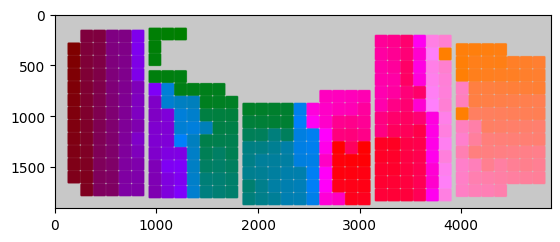

In [4]:
# Show the texture

texture_path = str(OUTPUTS_DIR / 'tmp.png')

aspec.SaveArrayTexture(texture_path)

import matplotlib.pyplot as plt
from matplotlib import image as mpimg

image = mpimg.imread(texture_path)

plt.imshow(image)
plt.show()

In [5]:
aspec.get_CellSpec() == aspec.CellSpec # This getter is redundant

True

In [6]:
# Get Strings

strings = list(aspec.Strings)
strings

In [7]:
string_zero = strings[0]

list_attrs(string_zero)

[('BypassDiodes', System.Collections.Generic.List[BypassDiode]),
 ('Cells', System.Collections.Generic.List[Cell]),
 ('Name', str),
 ('get_BypassDiodes', CLR.MethodBinding),
 ('get_Cells', CLR.MethodBinding),
 ('get_Name', CLR.MethodBinding),
 ('set_Name', CLR.MethodBinding)]

In [8]:
# Get Cells

string_zero_cells = list(string_zero.Cells)
print(f"{len(string_zero_cells)} cells of type {type(string_zero_cells[0])}")

96 cells of type <class 'SSCP.ShellPower.Cell'>


In [9]:
list_attrs(string_zero_cells[0])

[('Color', SixLabors.ImageSharp.PixelFormats.Rgba32),
 ('Pixels', System.Collections.Generic.List[Pair[Int32]]),
 ('get_Color', CLR.MethodBinding),
 ('get_Pixels', CLR.MethodBinding),
 ('set_Color', CLR.MethodBinding)]

In [10]:
# Pixels: a list of coordinates

cell_pixels = list(string_zero_cells[0].Pixels)

for pix in cell_pixels[:5]:
    print(pix.First, pix.Second)
print('etc...')

1178 134
1179 134
1180 134
1181 134
1182 134
etc...


In [11]:
string_zero_cells[0].Color.ToString()

'Rgba32(0, 127, 0, 255)'

# Manipulating Cells

Now we know how to navigate and obtain a reference to any string or cell, and get the pixels and color of each cell.

Let's put it in practice by adding every cell to one string.

In [12]:
# # Reload the aspec from the file
# aspec = Simulation.ArraySpec(
#     str(OUTPUTS_DIR / "2026-04-12_15h14m11s" / "rebalanced.png"),
#     str(INPUTS_DIR / "v4-ep9-guillotined-ascii.stl"),
#     str(INPUTS_DIR / "bypass_diodes.json")
# )
# first_string = aspec.Strings[0]

# not_in_string_1 = []
# for i, string in enumerate(aspec.Strings):
 
#     # Skip string 1
#     if i == 0:
#         continue
    
#     for cell in string.Cells:
#         not_in_string_1.append(cell)

# print(len(not_in_string_1))

# for cell in not_in_string_1:
#     ret = aspec.AddCellToCellString(cell, first_string)
#     # print(ret)

## Visualize Changes

We've now put all the cells on the same array, and we can use `Recolor` to update the colours, then display the result.

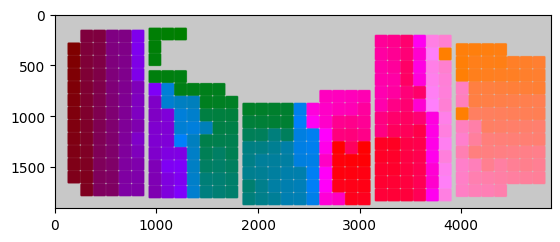

In [13]:
texture_path = str(OUTPUTS_DIR / 'tmp.png')

aspec.Recolor()

aspec.SaveArrayTexture(texture_path)
plt.imshow(mpimg.imread(texture_path))
plt.show()

To make the arrays easier to visualize, here is a function which converts to HSV instead (this helps distinguish strings).

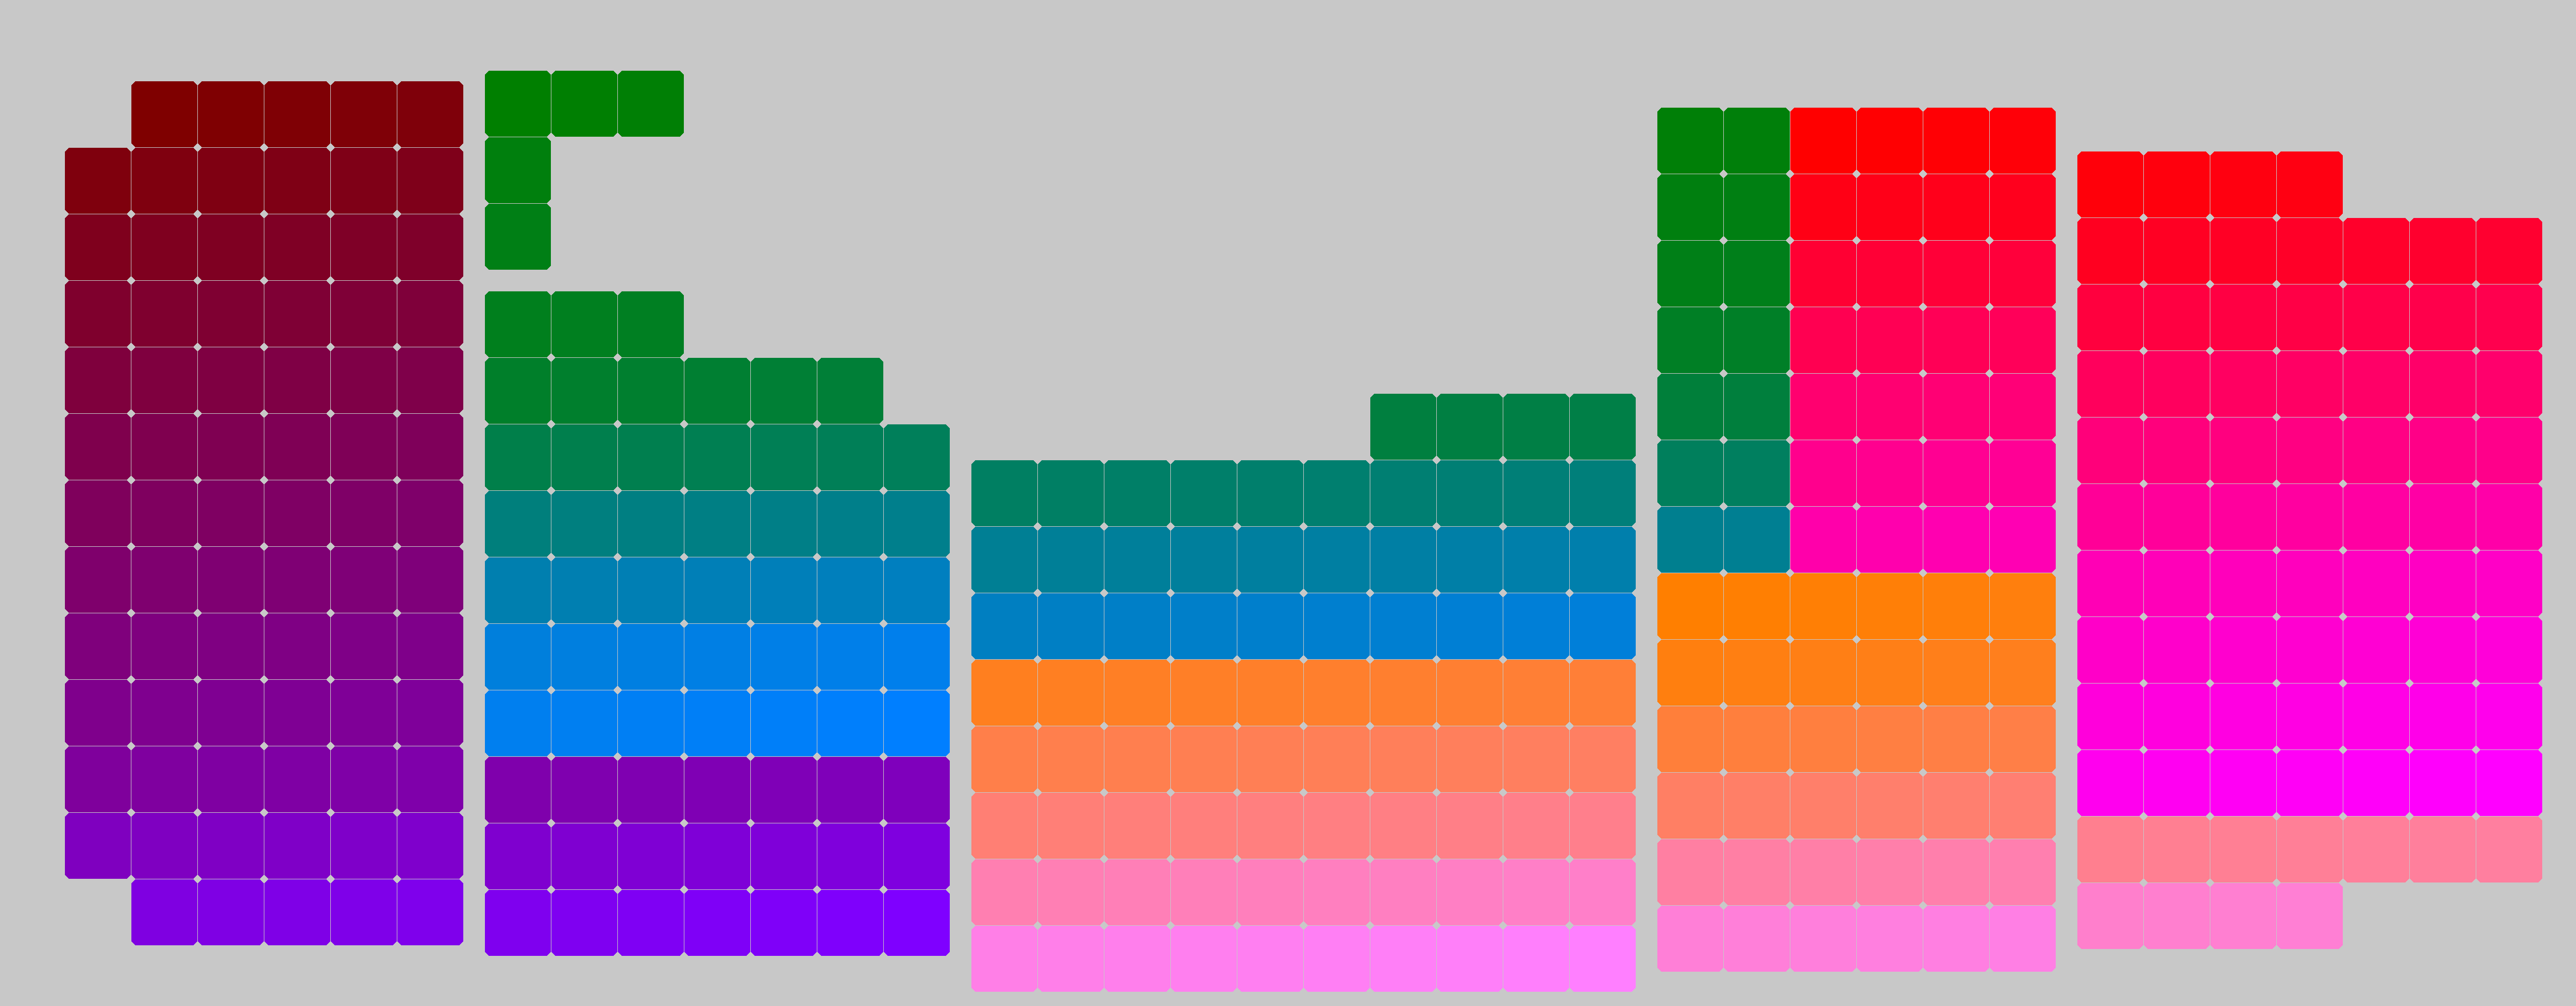

In [7]:
from PIL import Image
import math
import os
import colorsys
import random

def get_texture_hsv(array_spec, output_path) -> Image:
    width = array_spec.LayoutTexture.Width
    height = array_spec.LayoutTexture.Height
    image = Image.new("RGB", (width, height), color=(200, 200, 200))
    pixels = image.load()

    num_strings = len(array_spec.Strings)
    hues = [i / num_strings for i in range(num_strings)]
    random.shuffle(hues)  # Shuffle so adjacent strings aren't neighbouring hues

    for hue, string in zip(hues, array_spec.Strings):
        for cell in string.Cells:
            for px in cell.Pixels:
                x = px.First
                y = px.Second
                if 0 <= x < width and 0 <= y < height:
                    value = ((x / (width - 1)) + (y / (height - 1))) / 2
                    value = value * 0.5 + 0.5
                    rgb = colorsys.hsv_to_rgb(hue, 1.0, value)
                    pixels[x, y] = tuple(int(c * 255) for c in rgb)

    image.save(output_path)
    return image


def get_texture_rg_sorted_blue(array_spec, output_path) -> Image:
    width = array_spec.LayoutTexture.Width
    height = array_spec.LayoutTexture.Height
    image = Image.new("RGB", (width, height), color=(200, 200, 200))
    pixels = image.load()

    # Group cells by (R, G), storing (first_pixel_position, all_pixels)
    from collections import defaultdict
    rg_groups = defaultdict(list)
    for string in array_spec.Strings:
        for cell in string.Cells:
            r, g = cell.Color.R, cell.Color.G
            cell_pixels = [(px.First, px.Second) for px in cell.Pixels
                           if 0 <= px.First < width and 0 <= px.Second < height]
            if cell_pixels:
                first_px = min(cell_pixels, key=lambda p: (p[1], p[0]))  # row-major first
                rg_groups[(r, g)].append((first_px, cell_pixels))

    # Sort cells within each (R, G) group by first pixel position,
    # assign unique evenly-spaced B values across 0–255
    for (r, g), cells in rg_groups.items():
        cells.sort(key=lambda c: (c[0][1], c[0][0]))  # sort by first pixel, row-major
        num_cells = len(cells)
        for i, (_, cell_pixels) in enumerate(cells):
            b = int(i * 255 / (num_cells - 1)) if num_cells > 1 else 0
            for x, y in cell_pixels:
                pixels[x, y] = (r, g, b)

    image.save(output_path)
    return image


# Reload the aspec from the file
aspec = Simulation.ArraySpec(
    str(INPUTS_DIR / "manual_config_1_2026-04-11.png"),
    str(INPUTS_DIR / "v4-ep9-guillotined-ascii.stl"),
    str(INPUTS_DIR / "bypass_diodes.json")
)
aspec.Recolor()

output_dir = OUTPUTS_DIR / "modified"
os.makedirs(output_dir, exist_ok=True)

# hsv_texture = get_texture_hsv(aspec, output_dir / "texture_hsv.png")
rg_texture  = get_texture_rg_sorted_blue(aspec, output_dir / "initial_2026-04-12.png")

# display(hsv_texture)
display(rg_texture)